# A Hybrid Bucket Model

In `00_setup_and_motivation` you calibrated a six-parameter conceptual model by
gradient descent. Nothing about it was machine learning — it was an ordinary
rainfall-runoff model whose derivative happened to be available.

Now we spend that derivative on something you cannot do with SCE-UA. We are
going to take one *equation* out of the model — the relation between how much
water is in a store and how fast it drains — and replace it with a small neural
network, then train the network and the remaining physical parameters together,
through the water balance, against observed streamflow.

The question this notebook answers is not "is the hybrid better?" It is
**"better at what, and how would you know?"**

:::{admonition} Time check — 25 minutes
:class: tip
By the end you will be able to:
- place a learned closure inside a conceptual model without breaking mass balance
- warm-start a hybrid so that at step zero it reproduces your calibrated physics exactly
- evaluate it on a held-out *time* period with a validation split you are allowed to look at
- plot the learned function against the physical one it replaced, and read a physical claim off it
:::

## Motivation

Every conceptual model contains an equation somebody guessed. HBV's
storage-discharge relation is a good example: the fast reservoir releases a
fixed fraction of its contents each day, $q = K S$. That is a linear reservoir,
and it gives you an exponential recession.

Real recessions are not exponential. Hydrologists have known this for a century
and the usual fix is to write $q = a S^b$ and calibrate $b$ — you have replaced
one guess with a slightly more flexible guess. A differentiable model lets you
do something else: don't guess the functional form at all. Ask the data.

## What we'll cover

1. The model, written so a closure can be swapped in
2. Splitting time three ways, and why the middle block exists
3. The physics baseline
4. Where to put the question mark — taxonomy design **C**
5. Training the hybrid end to end
6. An honest comparison
7. Looking inside the learned function

In [1]:
# --- Colab bootstrap: installs the workshop package on first run -----------
try:
    import workshop_utils
except ImportError:
    %pip install -q "git+https://github.com/BennettHydroLab/differentiable_modeling_workshop.git"
    import workshop_utils

In [2]:
import copy
import time

import numpy as np
import torch
import matplotlib.pyplot as plt

from workshop_utils import nse, summary, hydrograph, set_style, COLORS, ParamMap, MLP
from workshop_utils.data import (
    load_basin, split_by_water_year, BASIN_TEMPERATE, BASIN_LABELS,
)

set_style()
torch.manual_seed(0)

SPINUP = 365      # days simulated then discarded, so states start somewhere sensible
S_REF = 10.0      # mm — a fixed scale for the network input, from training-period storage

## 1. The model, with a hole left in it

This is the same HBV-lite you calibrated in `00_setup_and_motivation`: one
soil-moisture store feeding a fast and a slow linear reservoir, six parameters,
batched over a leading parameter dimension so the only Python loop is over time.

One thing has changed. The line that computes the fast reservoir's outflow now
reads

```python
k = K_fast                      if closure is None else
    sigmoid(logit(K_fast) + closure(S_fast / S_REF))
```

Read that carefully, because the shape of it is the whole design:

- The network outputs a **correction to the physical parameter**, not the flux
  itself. When the network outputs zero, `k` is exactly `K_fast` and the model
  *is* the physics. There is no version of this model that cannot reproduce
  what you calibrated.
- The release is a **fraction** `k` in $(0, 1)$, multiplied by the storage. So
  $0 \le q \le S$ by construction: the reservoir can never discharge water it
  does not have, and can never discharge a negative amount. **Mass balance is
  structural, not learned.** This matters — it is the difference between a
  hybrid model and a regression that happens to have physics nearby.
- The sigmoid is the same range-map `ParamMap` applies to $\theta$, and the same
  device {cite}`lamichhane2025dynamic` uses to keep an LSTM's output inside
  published SNOW-17 parameter ranges. We write it out by hand here so you can
  see it.

In the workshop's notation (`resources/research_brief.md` §1): $\mathbf{u}$ is
the state vector, $\mathbf{x}$ the forcings, $\boldsymbol{\theta}$ the physical
parameters, $\boldsymbol{\varphi}$ the network weights, and
$\mathrm{NN}_\varphi$ the learned closure. This model is canonical form **(2)**,

$$\frac{d\mathbf{u}}{dt} = f\big(\mathbf{u}, \mathbf{x}, \boldsymbol{\theta}, \mathrm{NN}_\varphi(\mathbf{u})\big),$$

which the brief's taxonomy calls design **C**, *learned process / closure* — the
same row as Kalauni's "Resistance NN" {cite}`kalauni2025hybrid`.

In [3]:
PARAM_NAMES = ["FC", "beta", "LP", "K_fast", "K_slow", "PERC"]

LO = torch.tensor([ 50., 1.0, 0.3, 0.05, 0.005, 0.1])
HI = torch.tensor([500., 5.0, 1.0, 0.60, 0.150, 3.0])
pmap = ParamMap(LO, HI)


def logit(p):
    """Inverse of sigmoid. Lets us express a network output as a correction."""
    return torch.log(p / (1 - p))


def simulate(P, E, theta, closure=None, u0=(50., 5., 20.), keep_states=False):
    """HBV-lite, optionally with a learned storage-discharge closure.

    P, E    : (time,) precipitation and PET, mm/day
    theta   : (n, 6) physical parameter sets
    closure : NN_phi, or None for pure physics
    returns : (time, n) simulated discharge, mm/day
    """
    FC, beta, LP, K_fast, K_slow, PERC = theta.T
    n = theta.shape[0]

    # u = (soil store, fast reservoir, slow reservoir)
    S_soil = torch.full((n,), u0[0])
    S_fast = torch.full((n,), u0[1])
    S_slow = torch.full((n,), u0[2])

    discharge, released, stored = [], [], []
    for t in range(P.shape[0]):
        wetness = torch.clamp(S_soil / FC, 0., 1.)
        recharge = P[t] * wetness ** beta

        et = E[t] * torch.clamp(S_soil / (LP * FC), 0., 1.)
        S_soil = torch.clamp(S_soil + P[t] - recharge - et, min=0.)

        perc = torch.minimum(PERC, S_fast)
        S_fast = S_fast + recharge - perc

        # --- the one line the network is allowed to touch --------------------
        if closure is None:
            k = K_fast * torch.ones(n)
        else:
            k = torch.sigmoid(logit(K_fast) + closure((S_fast / S_REF).unsqueeze(-1)).squeeze(-1))
        q_fast = k * S_fast
        S_fast = S_fast - q_fast
        # ---------------------------------------------------------------------

        S_slow = S_slow + perc
        q_slow = K_slow * S_slow
        S_slow = S_slow - q_slow

        discharge.append(q_fast + q_slow)
        if keep_states:
            released.append(k)
            stored.append(S_fast)

    Q = torch.stack(discharge)
    if keep_states:
        return Q, torch.stack(stored), torch.stack(released)
    return Q

## 2. Three blocks of time, not two

`00_setup_and_motivation` split the record into train and test. That was enough
when the only thing being fitted was six numbers with hard physical bounds. It
is **not** enough now.

The reason is that a hybrid model gives you a new knob you did not have before:
*how long to train*. A network with a few hundred weights fitted to two water
years will, given enough gradient steps, start memorizing individual storm
events. You need to decide when to stop — and if you decide that by watching
the test score, your test score is no longer a test score. It is a training
score with extra steps.

So we cut the record three ways, chronologically:

| Block | Water years | Used for |
|---|---|---|
| Train | 1998-1999 | computing the loss and the gradient |
| Validation | 2000-2001 | deciding when to stop |
| Test | 2002-2004 | reported once, at the end |

Each block gets a 365-day spin-up that is simulated and then discarded. And the
split is in **time**, never at random across days — adjacent days in a
hydrograph are nearly the same day, so a random split lets a flexible model
interpolate its way to a beautiful and meaningless score. Both presenter papers
split chronologically for exactly this reason {cite}`lamichhane2025dynamic,kalauni2025hybrid`.

In [4]:
ds = load_basin(BASIN_TEMPERATE)


def block(test_years):
    """Pull one (train, test) pair out of the record; we call it twice."""
    return split_by_water_year(ds, train=(1998, 1999), test=test_years, spinup_days=SPINUP)


def arrays(d):
    return tuple(torch.tensor(d[v].values, dtype=torch.float32)
                 for v in ["prcp", "pet", "qobs"])


P,  E,  Q  = arrays(block((2000, 2001))["train"])       # WY1998-1999
Pv, Ev, Qv = arrays(block((2000, 2001))["test"])        # WY2000-2001, validation
Pt, Et, Qt = arrays(block((2002, 2004))["test"])        # WY2002-2004, test

time_test = block((2002, 2004))["test"].time.values

print(f"{BASIN_LABELS[BASIN_TEMPERATE]}")
print(f"train      {len(P):5d} days   ({SPINUP} spin-up)")
print(f"validation {len(Pv):5d} days   ({SPINUP} spin-up)")
print(f"test       {len(Pt):5d} days   ({SPINUP} spin-up)")

Cowpasture River, VA (humid temperate)
train       1095 days   (365 spin-up)
validation  1096 days   (365 spin-up)
test        1461 days   (365 spin-up)


## 3. The physics baseline

Forty Adam steps on the six physical parameters, exactly as in
`00_setup_and_motivation`. This takes about half a minute.

A word on why we bother rerunning it rather than hard-coding the answer: the
comparison at the end is only worth anything if the baseline is *fairly*
calibrated. It is very easy to make a hybrid model look good by leaving the
physics under-fitted, and an audience that calibrates models for a living will
spot it immediately. So the physics gets the same optimizer, the same loss, and
more gradient steps than the hybrid will get.

In [5]:
t0 = time.time()

raw_phys = torch.zeros(1, 6, requires_grad=True)
opt = torch.optim.Adam([raw_phys], lr=0.25)

for step in range(40):
    opt.zero_grad()
    q_sim = simulate(P, E, pmap(raw_phys))[:, 0]
    loss = -nse(q_sim[SPINUP:], Q[SPINUP:])
    loss.backward()
    opt.step()
    if step % 10 == 0:
        print(f"  step {step:3d}   train NSE {-loss.item():.3f}")

t_phys = time.time() - t0
raw_phys = raw_phys.detach()
theta_phys = pmap(raw_phys)

print(f"\n40 steps in {t_phys:.1f} s ({t_phys/40:.2f} s/step)")
for name, value in zip(PARAM_NAMES, theta_phys[0].tolist()):
    print(f"  {name:8s} {value:8.3f}")

  step   0   train NSE 0.614


  step  10   train NSE 0.627


  step  20   train NSE 0.631


  step  30   train NSE 0.634



40 steps in 35.5 s (0.89 s/step)
  FC        198.558
  beta        4.560
  LP          0.897
  K_fast      0.322
  K_slow      0.028
  PERC        1.455


## 4. Where to put the question mark

Shen's framing of what differentiable modeling buys you is that classical
inversion can only ever ask $\boldsymbol{\theta} = ?$, while a differentiable
model lets you ask $f = ?$ {cite}`shen2023differentiable`. But you still have to
choose *which* $f$.

Our candidate is the fast reservoir's storage-discharge relation. Three reasons:

1. **It is a guess.** Nobody derived $q = K S$ from anything; it is the simplest
   relation with the right monotonicity.
2. **It is one-dimensional.** The learned function takes a single input, $S$, so
   we can plot the whole thing at the end and look at it. That is the entire
   selling point over a black box, and we should not give it up casually.
3. **It carries the event response.** In this basin about 60% of simulated
   discharge comes out of the fast store, so if the relation is wrong, it is
   wrong somewhere that matters.

The network is deliberately small — two hidden layers of 16 tanh units, 321
weights. `resources/NOTEBOOK_CONVENTIONS.md` is blunt about this: anything
bigger mostly buys you a longer coffee break. With 730 scored training days we
are already in a regime where capacity is a liability, which is a point we will
come back to with evidence.

:::{admonition} Initialize so the hybrid starts as the physics
:class: note
This is pitfall 4 in `resources/research_brief.md` §6, and it is the single
most common reason a hybrid model diverges before producing a useful gradient.
An untrained network dropped into a water balance emits nonsense, the states go
somewhere unphysical, and the first gradients are garbage.

Kalauni et al. handle it with 5000 steps of supervised pre-training against the
physics formula's own output. We can do something cheaper here because of how
we wrote the closure: **zero the last layer's weights and bias**, and the
network outputs exactly zero for every input, so `k == K_fast` and the hybrid
*is* the calibrated physics at step zero. You get the same guarantee for free.
:::

In [6]:
net = MLP(n_in=1, n_out=1, hidden=16, depth=2)

# Zero the output layer: NN_phi(.) == 0 everywhere, so the hybrid starts out
# numerically identical to the calibrated physics model.
with torch.no_grad():
    net.net[-1].weight.zero_()
    net.net[-1].bias.zero_()

n_weights = sum(p.numel() for p in net.parameters())
print(f"NN_phi: {n_weights} weights")

with torch.no_grad():
    q_check = simulate(P, E, theta_phys, closure=net)[:, 0]
    q_phys = simulate(P, E, theta_phys)[:, 0]
print(f"max |hybrid - physics| at step 0: {float((q_check - q_phys).abs().max()):.2e} mm/day")

NN_phi: 321 weights


max |hybrid - physics| at step 0: 0.00e+00 mm/day


### Validate before using the tool in anger

That last line is worth more than it looks. Before training anything, we
checked a known answer: with a zeroed output layer the hybrid must reproduce
the physics to floating-point precision, and it does. If it had not, something
in the closure plumbing was wrong and every subsequent number would have been
noise.

## 5. Training end to end

Now $\varphi$ and $\theta$ are optimized **together**, through 1,095 sequential
timesteps of the water balance. Two learning rates: the physical parameters get
a small one (0.05 rather than 0.25) because they are already near a good
solution and we want the network to do the new work, and the weights get 5e-3.

Three details that are doing real work:

- **Gradient clipping at norm 1.0.** A 1,095-step unrolled recurrence has the
  same exploding-gradient pathology as an RNN; both presenter papers clip.
- **We evaluate on validation every step.** A forward pass under `no_grad` is
  about a hundred times cheaper than a gradient step, so this is nearly free.
- **We keep the best-on-validation state**, not the last one.

In [7]:
t0 = time.time()

raw_hyb = raw_phys.clone().requires_grad_(True)
phi = list(net.parameters())

opt = torch.optim.Adam([
    {"params": [raw_hyb], "lr": 0.05},   # theta: already close, move it gently
    {"params": phi,       "lr": 5e-3},   # phi: the new degrees of freedom
])


def nse_on(P, E, Q, theta, closure=None):
    with torch.no_grad():
        return float(nse(simulate(P, E, theta, closure)[SPINUP:, 0], Q[SPINUP:]))


history, best = [], (-np.inf, None, 0)
for step in range(25):
    opt.zero_grad()
    q_sim = simulate(P, E, pmap(raw_hyb), closure=net)[:, 0]
    loss = -nse(q_sim[SPINUP:], Q[SPINUP:])
    loss.backward()
    torch.nn.utils.clip_grad_norm_([raw_hyb] + phi, 1.0)
    opt.step()

    val = nse_on(Pv, Ev, Qv, pmap(raw_hyb).detach(), net)
    history.append((-loss.item(), val))
    if val > best[0]:
        best = (val, (raw_hyb.detach().clone(), copy.deepcopy(net)), step + 1)
    if step % 5 == 0:
        print(f"  step {step:3d}   train NSE {-loss.item():.3f}   val NSE {val:.3f}")

t_hyb = time.time() - t0
raw_hyb_best, net_best = best[1]
theta_hyb = pmap(raw_hyb_best)

print(f"\n25 steps in {t_hyb:.1f} s ({t_hyb/25:.2f} s/step)")
print(f"best validation NSE {best[0]:.3f} at step {best[2]}")

  step   0   train NSE 0.635   val NSE 0.500


  step   5   train NSE 0.639   val NSE 0.511


  step  10   train NSE 0.646   val NSE 0.514


  step  15   train NSE 0.655   val NSE 0.522


  step  20   train NSE 0.664   val NSE 0.520



25 steps in 42.1 s (1.68 s/step)
best validation NSE 0.522 at step 18


### The training curve is the most useful figure in this notebook

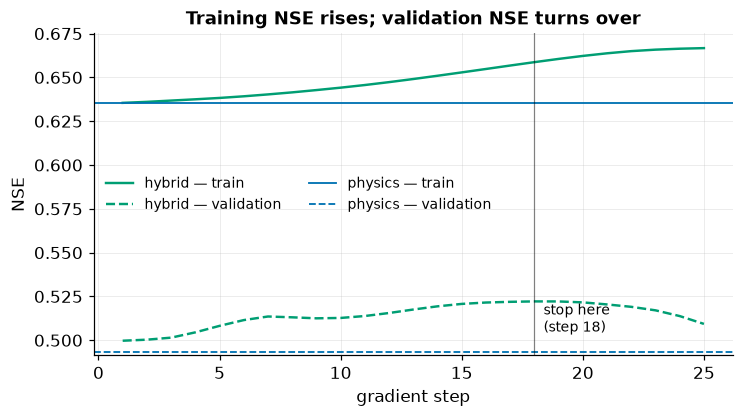

In [8]:
train_nse = [h[0] for h in history]
val_nse = [h[1] for h in history]

fig, ax = plt.subplots(figsize=(7.5, 3.8))
steps = np.arange(1, len(history) + 1)
ax.plot(steps, train_nse, color=COLORS["hybrid"], label="hybrid — train")
ax.plot(steps, val_nse, color=COLORS["hybrid"], ls="--", label="hybrid — validation")
ax.axhline(nse_on(P, E, Q, theta_phys), color=COLORS["physics"], lw=1.2,
           label="physics — train")
ax.axhline(nse_on(Pv, Ev, Qv, theta_phys), color=COLORS["physics"], ls="--", lw=1.2,
           label="physics — validation")
ax.axvline(best[2], color="k", lw=0.8, alpha=0.5)
ax.annotate(f"stop here\n(step {best[2]})", (best[2], min(val_nse)),
            textcoords="offset points", xytext=(6, 6), fontsize=9)
ax.set_xlabel("gradient step")
ax.set_ylabel("NSE")
ax.set_title("Training NSE rises; validation NSE turns over")
ax.legend(fontsize=9, ncol=2)
plt.show()

The solid green line goes up and keeps going up. The dashed green line rises,
flattens, and comes back down. That gap is the hybrid learning things about
WY1998-1999 that are not true of WY2000-2001 — 337 weights against 730 days of
data will do that, and no amount of hydrologic insight makes it go away.

This is why the validation block exists, and it is the honest version of a
choice every hybrid modeling paper makes somewhere. If we had trained for 40
steps and reported the result, the training score would have looked better and
the model would have been worse.

## 6. An honest comparison

Now — and only now — we touch the test years. Both models are scored on
WY2002-2004, which neither has seen in any form.

In [9]:
with torch.no_grad():
    q_test_phys = simulate(Pt, Et, theta_phys)[:, 0]
    q_test_hyb = simulate(Pt, Et, theta_hyb, closure=net_best)[:, 0]

m_phys = summary(q_test_phys[SPINUP:], Qt[SPINUP:])
m_hyb = summary(q_test_hyb[SPINUP:], Qt[SPINUP:])

print(f"{'':10s}{'physics':>10s}{'hybrid':>10s}{'change':>10s}")
print("-" * 40)
for key in m_phys:
    d = m_hyb[key] - m_phys[key]
    print(f"{key:10s}{m_phys[key]:10.3f}{m_hyb[key]:10.3f}{d:+10.3f}")

             physics    hybrid    change
----------------------------------------
NSE            0.613     0.629    +0.016
KGE            0.713     0.737    +0.024
logNSE         0.588     0.617    +0.029
PBIAS         -0.214     2.332    +2.546
RMSE           1.320     1.292    -0.028


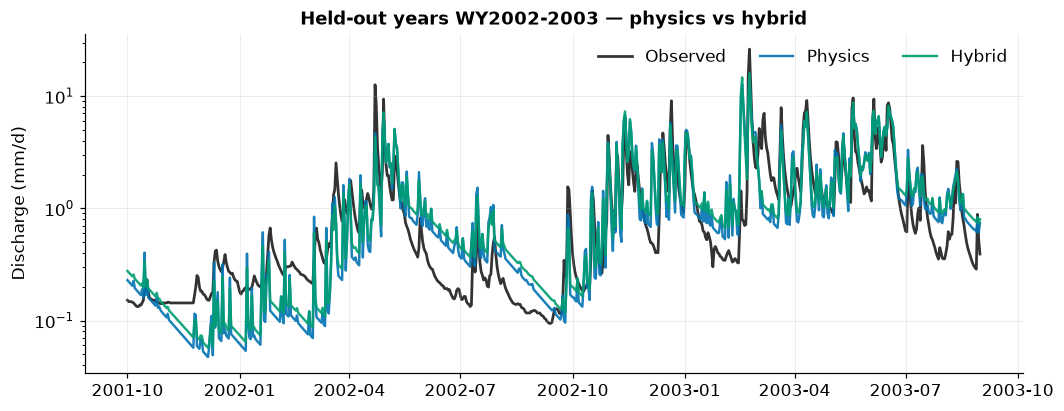

In [10]:
show = slice(SPINUP, SPINUP + 700)
ax = hydrograph(
    time_test[show],
    obs=Qt[show].numpy(),
    physics=q_test_phys[show].numpy(),
    hybrid=q_test_hyb[show].numpy(),
    title="Held-out years WY2002-2003 — physics vs hybrid",
    log=True,
)
plt.show()

:::{admonition} Read this before you get excited
:class: warning
The improvement is real and it is small. NSE moves by a couple of hundredths;
the hydrographs are hard to tell apart by eye at the peaks, and the visible
difference is in the recessions, which is why we plotted on a log axis.

Do not oversell a result like this, and be suspicious when someone else does.
A single basin, two water years of training, one closure: this is the smallest
honest version of the experiment.

And it is not a clean sweep. **Percent bias gets worse** — from -0.2% to about
+2.3%. Both are small enough to be unimportant here, but note what happened: we
optimized NSE, NSE went up, and the one quantity NSE is blind to is the one that
degraded. That is the standard failure mode of variance-based objectives, and
Kalauni et al. hit a sharper version of it — their hybrids win the diurnal cycle
at unseen sites and *lose* the long-term evaporative index to per-site-calibrated
physics, Spearman rho 0.88 against 0.68 {cite}`kalauni2025hybrid`.

What does make this result worth reporting is that NSE, KGE, log-NSE and RMSE
all moved together, and log-NSE in particular — which weights low flows, and
which the loss was not looking at — improved by more than NSE did. The gain is
in the recessions, which is precisely where a nonlinear storage-discharge
relation ought to show up.

`05_hybrid_as_diagnostic` puts the same closure in three different places and
shows that two of the three *do* buy training fit at the cost of held-out
skill. That contrast is the point.
:::

## 7. Looking inside

Here is the thing you cannot do with an LSTM. The closure is a function of one
variable, so we can simply plot it — against the physical relation it replaced,
over the range of storage the model actually visits.

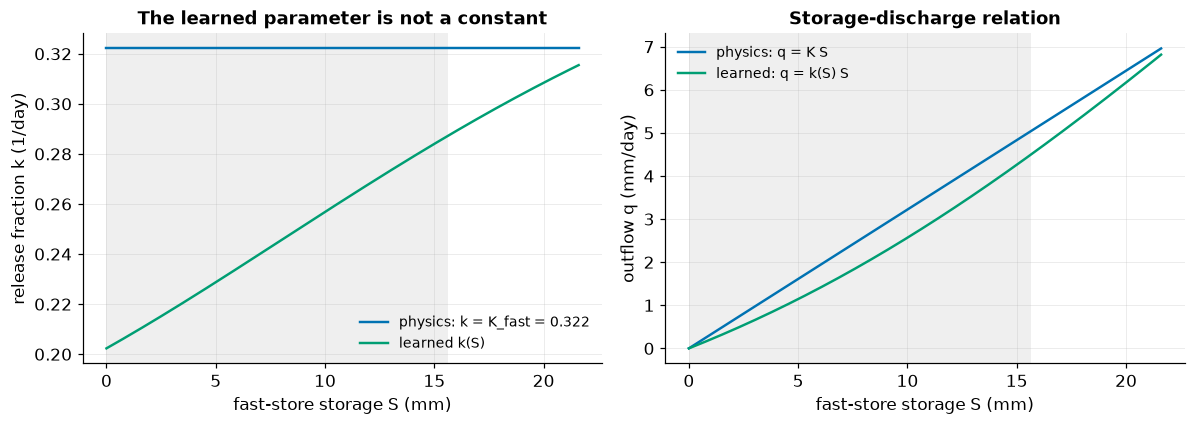

days with a non-empty fast store: 45 %
99th percentile of storage      : 15.64 mm


In [11]:
with torch.no_grad():
    _, S_seen, _ = simulate(P, E, theta_hyb, closure=net_best, keep_states=True)
    S_seen = S_seen[:, 0]
    s_hi = float(S_seen.quantile(0.999))

    grid = torch.linspace(0.0, s_hi, 200)
    K_fast_phys = float(theta_phys[0, 3])
    K_fast_hyb = float(theta_hyb[0, 3])
    k_learned = torch.sigmoid(
        logit(theta_hyb[0, 3]) + net_best((grid / S_REF).unsqueeze(-1)).squeeze(-1)
    )

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(grid, np.full_like(grid, K_fast_phys), color=COLORS["physics"],
         label=f"physics: k = K_fast = {K_fast_phys:.3f}")
ax1.plot(grid, k_learned, color=COLORS["hybrid"], label="learned k(S)")
ax1.set_xlabel("fast-store storage S (mm)")
ax1.set_ylabel("release fraction k (1/day)")
ax1.set_title("The learned parameter is not a constant")
ax1.legend(fontsize=9)

ax2.plot(grid, K_fast_phys * grid, color=COLORS["physics"], label="physics: q = K S")
ax2.plot(grid, k_learned * grid, color=COLORS["hybrid"], label="learned: q = k(S) S")
ax2.set_xlabel("fast-store storage S (mm)")
ax2.set_ylabel("outflow q (mm/day)")
ax2.set_title("Storage-discharge relation")
ax2.legend(fontsize=9)

# Shade where the model actually spends its time — the rest is extrapolation.
for ax in (ax1, ax2):
    ax.axvspan(0.0, float(S_seen.quantile(0.99)), color="0.5", alpha=0.12, lw=0)
plt.tight_layout()
plt.show()

print(f"days with a non-empty fast store: {float((S_seen > 0.05).float().mean())*100:.0f} %")
print(f"99th percentile of storage      : {float(S_seen.quantile(0.99)):.2f} mm")

The learned release fraction **increases with storage**. A fuller store does not
just discharge more water, it discharges a larger *share* of what it holds.

(The fast store is empty on most days — it is the event-response reservoir, so it
fills during storms and drains within days. The shaded band is where it actually
operates.)

That is a physical claim, and it is a familiar one: it says the storage-discharge
relation is convex, which is what you get from $q = a S^b$ with $b > 1$. So let's
read $b$ off the curve and see what the network thinks it is.

power law fitted to the learned closure:  q = 0.196 * S^1.12
the physics it replaced:                  q = 0.322 * S^1.00


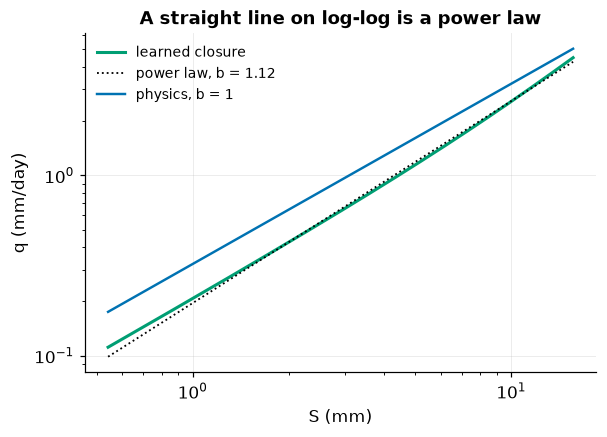

In [12]:
mask = (grid > 0.5) & (grid <= float(S_seen.quantile(0.99)))
b, log_a = np.polyfit(np.log(grid[mask].numpy()),
                      np.log((k_learned * grid)[mask].numpy()), 1)

print(f"power law fitted to the learned closure:  q = {np.exp(log_a):.3f} * S^{b:.2f}")
print(f"the physics it replaced:                  q = {K_fast_phys:.3f} * S^1.00")

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(grid[mask], (k_learned * grid)[mask], color=COLORS["hybrid"], lw=2,
          label="learned closure")
ax.loglog(grid[mask], np.exp(log_a) * grid[mask] ** b, color="k", ls=":", lw=1.2,
          label=f"power law, b = {b:.2f}")
ax.loglog(grid[mask], K_fast_phys * grid[mask], color=COLORS["physics"],
          label="physics, b = 1")
ax.set_xlabel("S (mm)")
ax.set_ylabel("q (mm/day)")
ax.set_title("A straight line on log-log is a power law")
ax.legend(fontsize=9)
plt.show()

Two things to take from that, one encouraging and one cautionary.

**Encouraging:** we did not tell the model to look for a power law. We gave it a
generic function approximator and an observed hydrograph, and it came back with
something that is nearly a power law with an exponent above one — which is what
the recession-analysis literature has been fitting by hand for decades. The
hybrid model recovered a piece of hydrology we already knew, which is exactly
the check you want before you believe it about something you *don't* know.

**Cautionary:** the exponent is only just above 1. This is a modest departure
from linearity, not a dramatic one, and the fit is only meaningful inside the
shaded band where the model actually spends time. Outside it the network is extrapolating, and a tanh
MLP extrapolates by flattening out — not by continuing the power law. If you
plan to run this model through a flood larger than anything in the training
record, that is a real problem and you should say so.

And the obvious next question — *if it is nearly a power law, can we just read
off the equation and put it back in the model?* — is the open research frontier
that Kalauni et al. flag explicitly: "how to distill them into interpretable and
sensible equations... is an open question that we take up in an upcoming study"
{cite}`kalauni2025hybrid`. `07_open_questions` picks this up.

## Your turn

**Exercise 1 (2 minutes).** Retrain the hybrid for 60 steps instead of 25,
keeping everything else the same, and plot the learned $k(S)$ from the *final*
state rather than the best-on-validation state. What happens to the shape of the
curve, and what does that tell you about where the extra training NSE came from?

**Exercise 2 (5 minutes).** Move the closure to the slow reservoir instead: make
`k_slow` the learned quantity and leave the fast store linear. The baseflow
index at this basin is 0.50, so half the flow goes through that store. Does it
help more or less than the fast-store closure?

:::{dropdown} Solution — Exercise 1
Change `range(25)` to `range(60)` and plot with `net` rather than `net_best`.

Training NSE keeps climbing; validation NSE keeps falling. The learned $k(S)$
develops wiggles — local bumps and dips that have no hydrologic reading at all.
They are the network fitting individual storm events in WY1998-1999.

This is the most useful diagnostic you have for a hybrid model, and it is
available precisely because the closure is low-dimensional enough to plot. A
learned function that is smooth and monotone is making a structural claim about
the catchment. A learned function with six inflection points is memorizing. You
cannot make that judgment about an LSTM's hidden state.
:::

:::{dropdown} Solution — Exercise 2
Change the closure line to act on the slow store:

```python
k_slow_t = torch.sigmoid(logit(K_slow) + closure((S_slow / 30.).unsqueeze(-1)).squeeze(-1))
q_slow = k_slow_t * S_slow
```

It helps **less** — in our run the slow-store closure gained essentially nothing
on held-out NSE and the learned function stayed close to flat, while the
fast-store version gained a little on every metric.

The reading is not "the slow reservoir is fine." It is that on this basin, with
this loss, the data do not contain enough information to say otherwise. NSE is
dominated by high flows, and the slow store contributes mostly to low flows; the
gradient reaching that closure is weak. Try it again with a loss of
`0.5*(1 - nse) + 0.5*(1 - log_nse)` and the picture changes. Which closure
"helps" is a statement about your objective function as much as about the
catchment — and that is precisely the diagnostic logic of
`05_hybrid_as_diagnostic`.
:::

## Takeaways

- A learned closure goes **inside** the water balance, not after it. Writing the
  release as a fraction of storage keeps mass balance structural, so the network
  never gets the chance to invent water.
- **Warm-start so that the hybrid at step zero reproduces your calibrated
  physics exactly.** Zeroing the output layer of a correction-form closure buys
  this for free, and it means training can only improve on the baseline.
- A hybrid model needs a **validation block**. It has a knob — training length —
  that a six-parameter model does not, and the honest place to turn that knob is
  not the test set.
- The improvement on one basin with two water years is small. Report it that
  way. What makes it credible is that bias, log-NSE and NSE all moved the same
  direction, not the size of any one of them.
- The payoff you cannot get from a black box is the last figure: the learned
  storage-discharge relation is convex, with a fitted exponent just above 1.
  That is a **statement about the catchment** — modest, but one you can argue
  with, test on another basin, and eventually write down as an equation.

## Where next

`04_dynamic_parameterization` takes the same machinery somewhere stranger: a
network that emits a physical parameter *at every timestep*, so $\theta$ stops
being a number you search for and becomes a function of the weather.
`05_hybrid_as_diagnostic` uses the closure as an instrument to find out *where*
this model's physics is wrong.

## References

```{bibliography}
:filter: docname in docnames
```